In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

### Question a)

In [65]:
# Model parameters
x = 100.0
r = 0.10
T = 1.0

# Discretization parameters requested in the statement
M_values = [50, 150, 250]

# Monte Carlo sample sizes for the empirical convergence study
N_values = list(range(1000, 51001, 2000))

# Confidence level
alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

In [66]:
def simulate_bachelier_paths(N, M, x=100.0, T=1.0, seed=None):
    """
    Simulate N paths of the Bachelier model:
        X_t^x = x + B_t
    on a uniform grid with M time steps over [0, T].

    Returns
    -------
    X : ndarray of shape (N, M+1)
        Simulated paths of X on the grid.
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / M
    dB = np.sqrt(dt) * np.random.randn(N, M)
    B = np.cumsum(dB, axis=1)
    B = np.concatenate([np.zeros((N, 1)), B], axis=1)

    X = x + B
    return X


def approximate_integral(X, T=1.0):
    """
    Approximate the time integral using the formula required in the statement:
        int_0^T X_t dt ≈ (T/M) * sum_{k=0}^M X_{kT/M}

    Parameters
    ----------
    X : ndarray of shape (N, M+1)

    Returns
    -------
    integral_approx : ndarray of shape (N,)
    """
    M = X.shape[1] - 1
    return (T / M) * np.sum(X, axis=1)


def payoff_complex_asian(X, x_strike=100.0, barrier_level=110.0, T=1.0):
    """
    Payoff:
        1_{ int_0^T X_t dt < 110 } * (X_T - 100)_+

    Parameters
    ----------
    X : ndarray of shape (N, M+1)

    Returns
    -------
    payoff : ndarray of shape (N,)
    """
    integral_approx = approximate_integral(X, T=T)
    terminal_value = X[:, -1]

    indicator = (integral_approx < barrier_level).astype(float)
    call_part = np.maximum(terminal_value - x_strike, 0.0)

    return indicator * call_part

In [67]:
def monte_carlo_price(N, M, x=100.0, r=0.10, T=1.0, seed=None):
    """
    Monte Carlo estimator of the discounted price.

    Returns
    -------
    results : dict
        Contains the estimator, empirical variance, standard error,
        confidence interval, and raw discounted payoffs.
    """
    X = simulate_bachelier_paths(N=N, M=M, x=x, T=T, seed=seed)
    payoff = payoff_complex_asian(X, x_strike=100.0, barrier_level=110.0, T=T)

    discounted_payoff = np.exp(-r * T) * payoff

    price_estimate = np.mean(discounted_payoff)

    # Empirical variance of the sample
    sample_variance = np.var(discounted_payoff, ddof=1)

    # Variance of the Monte Carlo estimator
    estimator_variance = sample_variance / N
    standard_error = np.sqrt(estimator_variance)

    ci_lower = price_estimate - z_alpha * standard_error
    ci_upper = price_estimate + z_alpha * standard_error

    return {
        "N": N,
        "M": M,
        "price_estimate": price_estimate,
        "sample_variance": sample_variance,
        "estimator_variance": estimator_variance,
        "standard_error": standard_error,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "discounted_payoff": discounted_payoff
    }

In [68]:
test_result = monte_carlo_price(N=5000, M=50, x=x, r=r, T=T, seed=42)

print("Test configuration:")
print(f"N = {test_result['N']}, M = {test_result['M']}")
print(f"Price estimate       = {test_result['price_estimate']:.6f}")
print(f"Sample variance      = {test_result['sample_variance']:.6f}")
print(f"Estimator variance   = {test_result['estimator_variance']:.8f}")
print(f"Standard error       = {test_result['standard_error']:.6f}")
print(f"95% CI               = [{test_result['ci_lower']:.6f}, {test_result['ci_upper']:.6f}]")

Test configuration:
N = 5000, M = 50
Price estimate       = 0.361023
Sample variance      = 0.284009
Estimator variance   = 0.00005680
Standard error       = 0.007537
95% CI               = [0.346252, 0.375795]


In [69]:
results = []

for M in M_values:
    for N in N_values:
        res = monte_carlo_price(N=N, M=M, x=x, r=r, T=T, seed=123)
        results.append({
            "M": res["M"],
            "N": res["N"],
            "Price estimate": res["price_estimate"],
            "Sample variance": res["sample_variance"],
            "Estimator variance": res["estimator_variance"],
            "Standard error": res["standard_error"],
            "CI lower": res["ci_lower"],
            "CI upper": res["ci_upper"]
        })

results_df = pd.DataFrame(results)
results_df.head()

,M,N,Price estimate,Sample variance,Estimator variance,Standard error,CI lower,CI upper
0,50,1000,0.384952,0.322325,0.000322,0.017953,0.349764,0.420140
1,50,3000,0.361855,0.283108,0.000094,0.009714,0.342815,0.380895
2,50,5000,0.367035,0.288326,0.000058,0.007594,0.352151,0.381918
3,50,7000,0.367048,0.289673,0.000041,0.006433,0.354440,0.379657
4,50,9000,0.364680,0.287731,0.000032,0.005654,0.353598,0.375762


In [70]:
summary_table = results_df.copy()
summary_table["95% CI"] = summary_table.apply(
    lambda row: f"[{row['CI lower']:.5f}, {row['CI upper']:.5f}]",
    axis=1
)

summary_table = summary_table[
    ["M", "N", "Price estimate", "Sample variance", "Estimator variance", "Standard error", "95% CI"]
]

summary_table.head(12)

,M,N,Price estimate,Sample variance,Estimator variance,Standard error,95% CI
0,50,1000,0.384952,0.322325,0.000322,0.017953,"[0.34976, 0.42014]"
1,50,3000,0.361855,0.283108,0.000094,0.009714,"[0.34282, 0.38089]"
2,50,5000,0.367035,0.288326,0.000058,0.007594,"[0.35215, 0.38192]"
3,50,7000,0.367048,0.289673,0.000041,0.006433,"[0.35444, 0.37966]"
4,50,9000,0.364680,0.287731,0.000032,0.005654,"[0.35360, 0.37576]"
5,50,11000,0.364776,0.287380,0.000026,0.005111,"[0.35476, 0.37479]"
6,50,13000,0.365028,0.287724,0.000022,0.004705,"[0.35581, 0.37425]"
7,50,15000,0.362883,0.287025,0.000019,0.004374,"[0.35431, 0.37146]"
8,50,17000,0.362689,0.285518,0.000017,0.004098,"[0.35466, 0.37072]"
9,50,19000,0.364805,0.285945,0.000015,0.003879,"[0.35720, 0.37241]"


In [71]:
final_results = results_df.groupby("M").tail(1).reset_index(drop=True)
final_results["95% CI"] = final_results.apply(
    lambda row: f"[{row['CI lower']:.6f}, {row['CI upper']:.6f}]",
    axis=1
)

final_results[["M", "N", "Price estimate", "Sample variance", "Estimator variance", "Standard error", "95% CI"]]

,M,N,Price estimate,Sample variance,Estimator variance,Standard error,95% CI
0,50,51000,0.364212,0.284251,0.000006,0.002361,"[0.359584, 0.368839]"
1,150,51000,0.363835,0.283481,0.000006,0.002358,"[0.359214, 0.368456]"
2,250,51000,0.363415,0.283415,0.000006,0.002357,"[0.358795, 0.368036]"


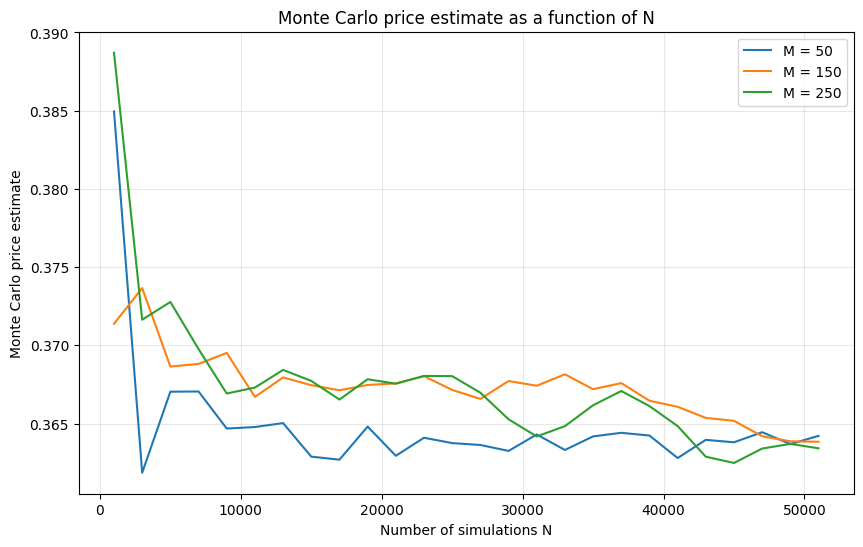

In [72]:
plt.figure(figsize=(10, 6))

for M in M_values:
    subset = results_df[results_df["M"] == M]
    plt.plot(subset["N"], subset["Price estimate"], label=f"M = {M}")

plt.xlabel("Number of simulations N")
plt.ylabel("Monte Carlo price estimate")
plt.title("Monte Carlo price estimate as a function of N")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

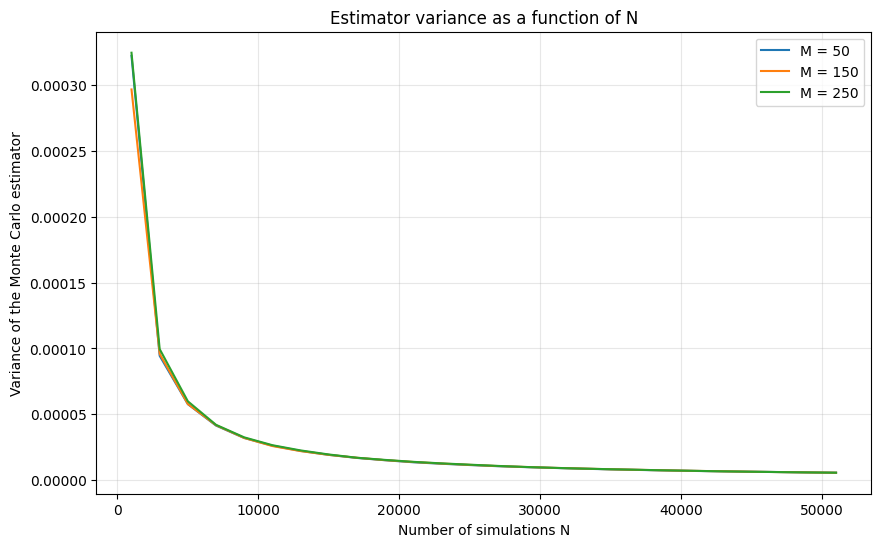

In [73]:
plt.figure(figsize=(10, 6))

for M in M_values:
    subset = results_df[results_df["M"] == M]
    plt.plot(subset["N"], subset["Estimator variance"], label=f"M = {M}")

plt.xlabel("Number of simulations N")
plt.ylabel("Variance of the Monte Carlo estimator")
plt.title("Estimator variance as a function of N")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question b)


In [74]:
# Values of epsilon to test
epsilon_values = [0.1, 0.25, 0.5, 1.0, 2.0]

In [75]:
def simulate_brownian_paths(N, M, T=1.0, seed=None):
    """
    Simulate N Brownian paths on a uniform grid with M time steps over [0, T].

    Returns
    -------
    B : ndarray of shape (N, M+1)
        Brownian motion sampled on the grid.
    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / M
    dB = np.sqrt(dt) * np.random.randn(N, M)
    B = np.cumsum(dB, axis=1)
    B = np.concatenate([np.zeros((N, 1)), B], axis=1)

    return B

In [76]:
def build_bachelier_paths_from_brownian(B, x):
    """
    Build Bachelier paths X_t^x = x + B_t from Brownian paths B.
    """
    return x + B

In [77]:
def discounted_payoff_from_brownian(B, x, r=0.10, T=1.0):
    """
    Compute the discounted payoff from Brownian paths for a given initial value x.
    """
    X = build_bachelier_paths_from_brownian(B, x=x)
    payoff = payoff_complex_asian(X, x_strike=100.0, barrier_level=110.0, T=T)
    return np.exp(-r * T) * payoff

In [78]:
def finite_difference_delta_central(N, M, epsilon, x=100.0, r=0.10, T=1.0, seed=None):
    """
    Estimate Delta using the centered finite-difference estimator:
        Delta ≈ (P(x+epsilon) - P(x-epsilon)) / (2 epsilon)

    The same Brownian paths are used for x+epsilon and x-epsilon
    (common random numbers).

    Returns
    -------
    results : dict
        Contains the estimator, empirical variance, standard error,
        confidence interval, and the simulated sample of Delta contributions.
    """
    B = simulate_brownian_paths(N=N, M=M, T=T, seed=seed)

    discounted_plus = discounted_payoff_from_brownian(B, x=x + epsilon, r=r, T=T)
    discounted_minus = discounted_payoff_from_brownian(B, x=x - epsilon, r=r, T=T)

    delta_sample = (discounted_plus - discounted_minus) / (2.0 * epsilon)

    delta_estimate = np.mean(delta_sample)
    sample_variance = np.var(delta_sample, ddof=1)
    estimator_variance = sample_variance / N
    standard_error = np.sqrt(estimator_variance)

    ci_lower = delta_estimate - z_alpha * standard_error
    ci_upper = delta_estimate + z_alpha * standard_error

    return {
        "N": N,
        "M": M,
        "epsilon": epsilon,
        "delta_estimate": delta_estimate,
        "sample_variance": sample_variance,
        "estimator_variance": estimator_variance,
        "standard_error": standard_error,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "delta_sample": delta_sample
    }

In [79]:
test_fd = finite_difference_delta_central(
    N=5000,
    M=50,
    epsilon=1.0,
    x=x,
    r=r,
    T=T,
    seed=42
)

print("Test configuration:")
print(f"N = {test_fd['N']}, M = {test_fd['M']}, epsilon = {test_fd['epsilon']}")
print(f"Delta estimate       = {test_fd['delta_estimate']:.6f}")
print(f"Sample variance      = {test_fd['sample_variance']:.6f}")
print(f"Estimator variance   = {test_fd['estimator_variance']:.8f}")
print(f"Standard error       = {test_fd['standard_error']:.6f}")
print(f"95% CI               = [{test_fd['ci_lower']:.6f}, {test_fd['ci_upper']:.6f}]")

Test configuration:
N = 5000, M = 50, epsilon = 1.0
Delta estimate       = 0.453506
Sample variance      = 0.104523
Estimator variance   = 0.00002090
Standard error       = 0.004572
95% CI               = [0.444544, 0.462467]


In [80]:
fd_results = []

for M in M_values:
    for epsilon in epsilon_values:
        for N in N_values:
            res = finite_difference_delta_central(
                N=N,
                M=M,
                epsilon=epsilon,
                x=x,
                r=r,
                T=T,
                seed=123
            )

            fd_results.append({
                "M": res["M"],
                "N": res["N"],
                "epsilon": res["epsilon"],
                "Delta estimate": res["delta_estimate"],
                "Sample variance": res["sample_variance"],
                "Estimator variance": res["estimator_variance"],
                "Standard error": res["standard_error"],
                "CI lower": res["ci_lower"],
                "CI upper": res["ci_upper"]
            })

fd_results_df = pd.DataFrame(fd_results)
fd_results_df.head()

,M,N,epsilon,Delta estimate,Sample variance,Estimator variance,Standard error,CI lower,CI upper
0,50,1000,0.1,0.467861,0.193544,0.000194,0.013912,0.440594,0.495128
1,50,3000,0.1,0.452663,0.195076,0.000065,0.008064,0.436859,0.468468
2,50,5000,0.1,0.455670,0.194085,0.000039,0.006230,0.443459,0.467882
3,50,7000,0.1,0.452620,0.193982,0.000028,0.005264,0.442302,0.462937
4,50,9000,0.1,0.451923,0.193640,0.000022,0.004638,0.442832,0.461014


In [81]:
fd_final_results = fd_results_df.groupby(["M", "epsilon"]).tail(1).reset_index(drop=True)

fd_final_results["95% CI"] = fd_final_results.apply(
    lambda row: f"[{row['CI lower']:.6f}, {row['CI upper']:.6f}]",
    axis=1
)

fd_final_results[
    ["M", "epsilon", "N", "Delta estimate", "Sample variance",
     "Estimator variance", "Standard error", "95% CI"]
]

,M,epsilon,N,Delta estimate,Sample variance,Estimator variance,Standard error,95% CI
0,50,0.10,51000,0.452258,0.193789,3.799786e-06,0.001949,"[0.448438, 0.456079]"
1,50,0.25,51000,0.452378,0.177564,3.481643e-06,0.001866,"[0.448721, 0.456035]"
2,50,0.50,51000,0.452590,0.151850,2.977456e-06,0.001726,"[0.449208, 0.455972]"
3,50,1.00,51000,0.452692,0.106168,2.081735e-06,0.001443,"[0.449864, 0.455520]"
4,50,2.00,51000,0.452567,0.047783,9.369199e-07,0.000968,"[0.450670, 0.454464]"
5,150,0.10,51000,0.452461,0.193704,3.798122e-06,0.001949,"[0.448641, 0.456281]"
6,150,0.25,51000,0.452619,0.177648,3.483287e-06,0.001866,"[0.448961, 0.456277]"
7,150,0.50,51000,0.452909,0.151611,2.972764e-06,0.001724,"[0.449530, 0.456288]"
8,150,1.00,51000,0.452840,0.105979,2.078011e-06,0.001442,"[0.450015, 0.455665]"
9,150,2.00,51000,0.452752,0.047709,9.354686e-07,0.000967,"[0.450857, 0.454648]"


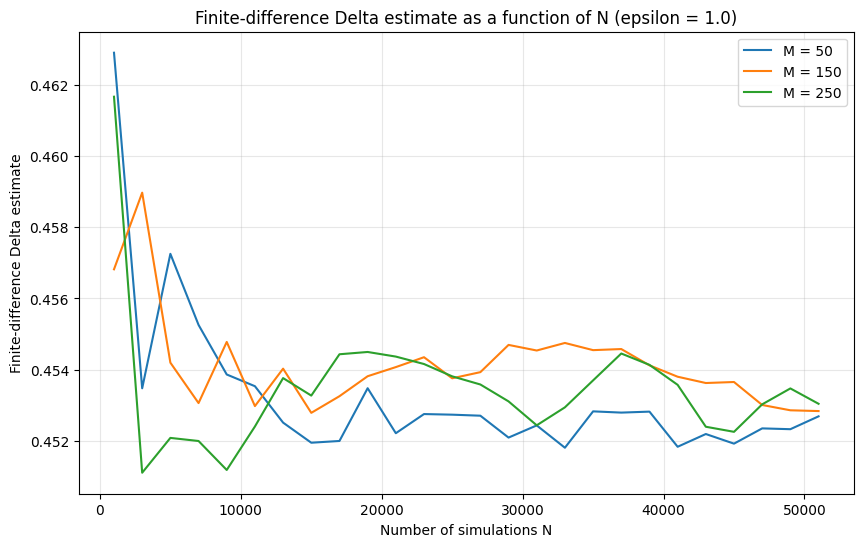

In [82]:
epsilon_plot = 1.0

plt.figure(figsize=(10, 6))

for M in M_values:
    subset = fd_results_df[
        (fd_results_df["M"] == M) &
        (fd_results_df["epsilon"] == epsilon_plot)
    ]
    plt.plot(subset["N"], subset["Delta estimate"], label=f"M = {M}")

plt.xlabel("Number of simulations N")
plt.ylabel("Finite-difference Delta estimate")
plt.title(f"Finite-difference Delta estimate as a function of N (epsilon = {epsilon_plot})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

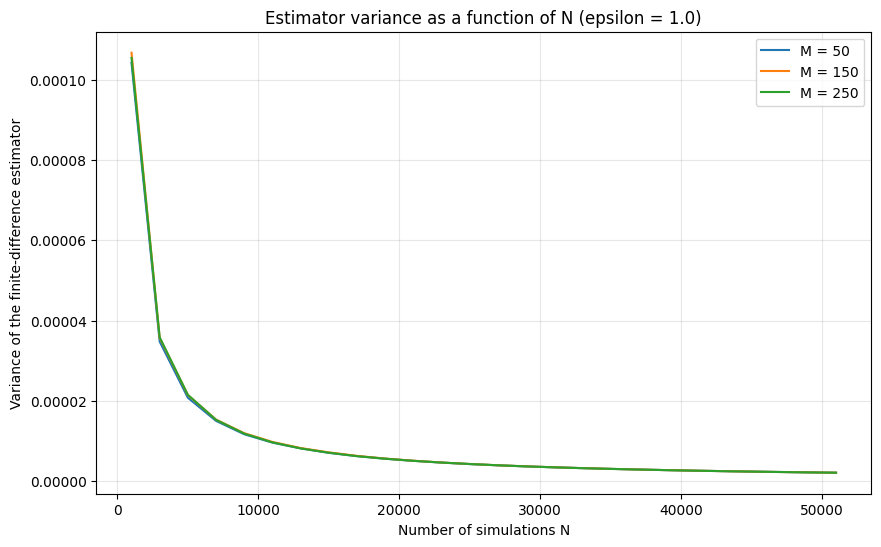

In [83]:
plt.figure(figsize=(10, 6))

for M in M_values:
    subset = fd_results_df[
        (fd_results_df["M"] == M) &
        (fd_results_df["epsilon"] == epsilon_plot)
    ]
    plt.plot(subset["N"], subset["Estimator variance"], label=f"M = {M}")

plt.xlabel("Number of simulations N")
plt.ylabel("Variance of the finite-difference estimator")
plt.title(f"Estimator variance as a function of N (epsilon = {epsilon_plot})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [84]:
M_fixed = 150
N_fixed = 51000

subset_eps = fd_results_df[
    (fd_results_df["M"] == M_fixed) &
    (fd_results_df["N"] == N_fixed)
].sort_values("epsilon")

subset_eps[["epsilon", "Delta estimate", "Sample variance",
            "Estimator variance", "Standard error", "CI lower", "CI upper"]]

,epsilon,Delta estimate,Sample variance,Estimator variance,Standard error,CI lower,CI upper
155,0.10,0.452461,0.193704,3.798122e-06,0.001949,0.448641,0.456281
181,0.25,0.452619,0.177648,3.483287e-06,0.001866,0.448961,0.456277
207,0.50,0.452909,0.151611,2.972764e-06,0.001724,0.449530,0.456288
233,1.00,0.452840,0.105979,2.078011e-06,0.001442,0.450015,0.455665
259,2.00,0.452752,0.047709,9.354686e-07,0.000967,0.450857,0.454648


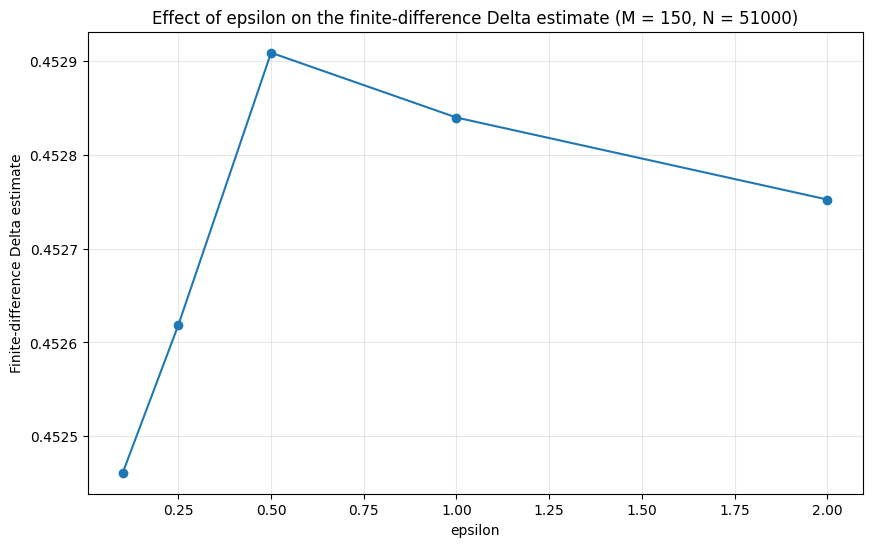

In [85]:
plt.figure(figsize=(10, 6))
plt.plot(subset_eps["epsilon"], subset_eps["Delta estimate"], marker="o")

plt.xlabel("epsilon")
plt.ylabel("Finite-difference Delta estimate")
plt.title(f"Effect of epsilon on the finite-difference Delta estimate (M = {M_fixed}, N = {N_fixed})")
plt.grid(True, alpha=0.3)
plt.show()

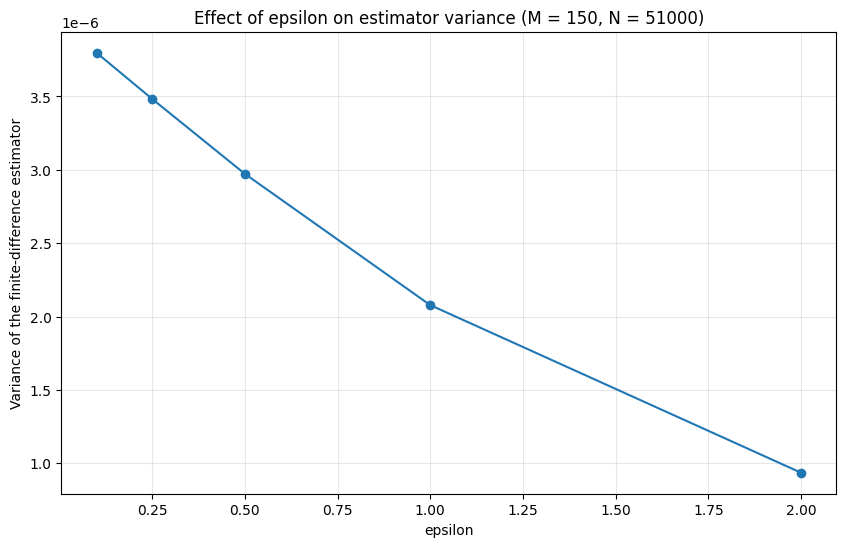

In [86]:
plt.figure(figsize=(10, 6))
plt.plot(subset_eps["epsilon"], subset_eps["Estimator variance"], marker="o")

plt.xlabel("epsilon")
plt.ylabel("Variance of the finite-difference estimator")
plt.title(f"Effect of epsilon on estimator variance (M = {M_fixed}, N = {N_fixed})")
plt.grid(True, alpha=0.3)
plt.show()

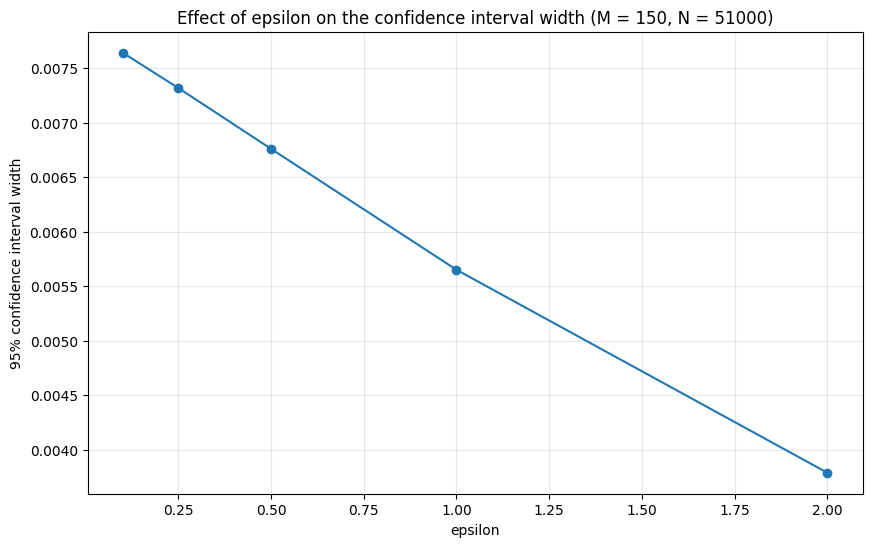

In [87]:
subset_eps = subset_eps.copy()
subset_eps["CI width"] = subset_eps["CI upper"] - subset_eps["CI lower"]

plt.figure(figsize=(10, 6))
plt.plot(subset_eps["epsilon"], subset_eps["CI width"], marker="o")

plt.xlabel("epsilon")
plt.ylabel("95% confidence interval width")
plt.title(f"Effect of epsilon on the confidence interval width (M = {M_fixed}, N = {N_fixed})")
plt.grid(True, alpha=0.3)
plt.show()

### Question c)

In [88]:
def simulate_brownian_paths(N, M, T=1.0, seed=None):
    """
    Simulate N Brownian paths on a uniform grid with M time steps over [0, T].

    """
    if seed is not None:
        np.random.seed(seed)

    dt = T / M
    dB = np.sqrt(dt) * np.random.randn(N, M)
    B = np.cumsum(dB, axis=1)
    B = np.concatenate([np.zeros((N, 1)), B], axis=1)

    return B, dB #From now on we're also returning dB

def approximate_stochastic_integral_s_dB(dB, T=1.0):
    """
    Approximate the Itô integral
        int_0^T s dB_s
    by the left-point discretization
        sum_{k=0}^{M-1} t_k * (B_{t_{k+1}} - B_{t_k}),
    where t_k = kT/M.

    Parameters
    ----------
    dB : ndarray of shape (N, M)
        Brownian increments.

    Returns
    -------
    integral_approx : ndarray of shape (N,)
    """
    N, M = dB.shape
    t_grid_left = np.arange(M) * (T / M)   # t_0, ..., t_{M-1}
    return np.sum(t_grid_left * dB, axis=1)

In [89]:
def malliavin_weight(B, dB, T=1.0):
    """
    Compute the Malliavin weight
        Pi = (4/T) B_T - (6/T^2) int_0^T s dB_s
    using the simulated Brownian path and the discretized Itô integral.
    """
    B_T = B[:, -1]
    int_s_dB = approximate_stochastic_integral_s_dB(dB, T=T)

    Pi = (4.0 / T) * B_T - (6.0 / (T ** 2)) * int_s_dB
    return Pi

In [90]:
def malliavin_delta_estimator(N, M, x=100.0, r=0.10, T=1.0, seed=None):
    """
    Monte Carlo estimator of Delta using the Malliavin weight formula.

    Returns
    -------
    results : dict
        Contains the estimator, empirical variance, standard error,
        confidence interval, and the simulated sample of contributions.
    """
    B, dB = simulate_brownian_paths(N=N, M=M, T=T, seed=seed)
    X = build_bachelier_paths_from_brownian(B, x=x)

    payoff = payoff_complex_asian(X, x_strike=100.0, barrier_level=110.0, T=T)
    Pi = malliavin_weight(B, dB, T=T)

    delta_sample = np.exp(-r * T) * payoff * Pi

    delta_estimate = np.mean(delta_sample)
    sample_variance = np.var(delta_sample, ddof=1)
    estimator_variance = sample_variance / N
    standard_error = np.sqrt(estimator_variance)

    ci_lower = delta_estimate - z_alpha * standard_error
    ci_upper = delta_estimate + z_alpha * standard_error

    return {
        "N": N,
        "M": M,
        "delta_estimate": delta_estimate,
        "sample_variance": sample_variance,
        "estimator_variance": estimator_variance,
        "standard_error": standard_error,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "delta_sample": delta_sample
    }

In [91]:
test_mal = malliavin_delta_estimator(
    N=5000,
    M=50,
    x=x,
    r=r,
    T=T,
    seed=42
)

print("Test configuration:")
print(f"N = {test_mal['N']}, M = {test_mal['M']}")
print(f"Delta estimate       = {test_mal['delta_estimate']:.6f}")
print(f"Sample variance      = {test_mal['sample_variance']:.6f}")
print(f"Estimator variance   = {test_mal['estimator_variance']:.8f}")
print(f"Standard error       = {test_mal['standard_error']:.6f}")
print(f"95% CI               = [{test_mal['ci_lower']:.6f}, {test_mal['ci_upper']:.6f}]")

Test configuration:
N = 5000, M = 50
Delta estimate       = 0.486683
Sample variance      = 2.476331
Estimator variance   = 0.00049527
Standard error       = 0.022255
95% CI               = [0.443065, 0.530301]


In [92]:
mal_results = []

for M in M_values:
    for N in N_values:
        res = malliavin_delta_estimator(
            N=N,
            M=M,
            x=x,
            r=r,
            T=T,
            seed=123
        )

        mal_results.append({
            "M": res["M"],
            "N": res["N"],
            "Delta estimate": res["delta_estimate"],
            "Sample variance": res["sample_variance"],
            "Estimator variance": res["estimator_variance"],
            "Standard error": res["standard_error"],
            "CI lower": res["ci_lower"],
            "CI upper": res["ci_upper"]
        })

mal_results_df = pd.DataFrame(mal_results)
mal_results_df.head()

,M,N,Delta estimate,Sample variance,Estimator variance,Standard error,CI lower,CI upper
0,50,1000,0.513179,2.926069,0.002926,0.054093,0.407158,0.619199
1,50,3000,0.449649,2.284464,0.000761,0.027595,0.395564,0.503734
2,50,5000,0.494787,2.450302,0.000490,0.022137,0.451398,0.538175
3,50,7000,0.495110,2.501407,0.000357,0.018904,0.458059,0.532160
4,50,9000,0.494276,2.547345,0.000283,0.016824,0.461302,0.527250


In [93]:
mal_final_results = mal_results_df.groupby("M").tail(1).reset_index(drop=True)

mal_final_results["95% CI"] = mal_final_results.apply(
    lambda row: f"[{row['CI lower']:.6f}, {row['CI upper']:.6f}]",
    axis=1
)

mal_final_results[
    ["M", "N", "Delta estimate", "Sample variance",
     "Estimator variance", "Standard error", "95% CI"]
]

,M,N,Delta estimate,Sample variance,Estimator variance,Standard error,95% CI
0,50,51000,0.490259,2.417154,0.000047,0.006884,"[0.476766, 0.503753]"
1,150,51000,0.472527,2.325132,0.000046,0.006752,"[0.459294, 0.485761]"
2,250,51000,0.459891,2.352877,0.000046,0.006792,"[0.446579, 0.473204]"


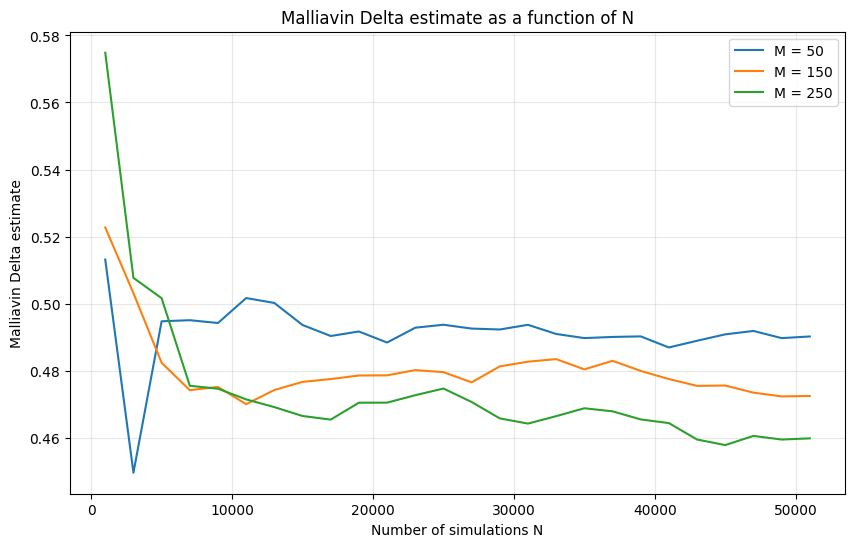

In [94]:
plt.figure(figsize=(10, 6))

for M in M_values:
    subset = mal_results_df[mal_results_df["M"] == M]
    plt.plot(subset["N"], subset["Delta estimate"], label=f"M = {M}")

plt.xlabel("Number of simulations N")
plt.ylabel("Malliavin Delta estimate")
plt.title("Malliavin Delta estimate as a function of N")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

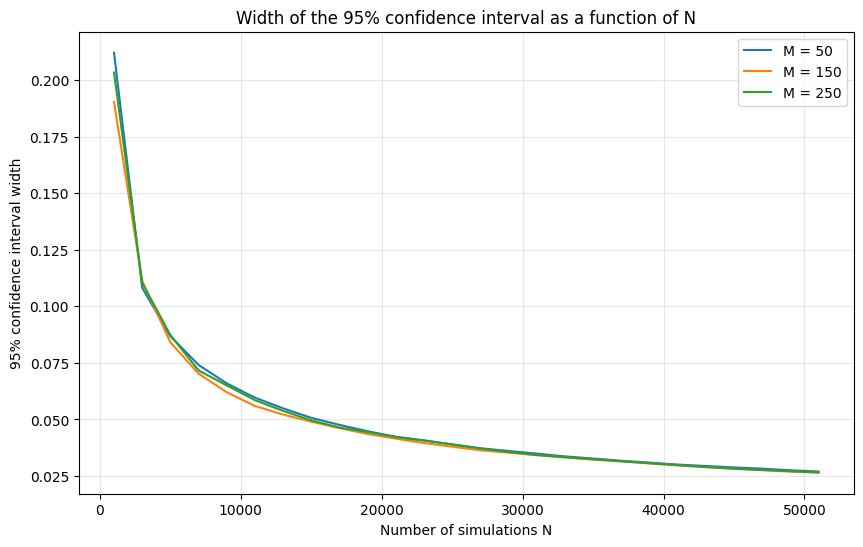

In [95]:
mal_results_df["CI width"] = mal_results_df["CI upper"] - mal_results_df["CI lower"]

plt.figure(figsize=(10, 6))

for M in M_values:
    subset = mal_results_df[mal_results_df["M"] == M]
    plt.plot(subset["N"], subset["CI width"], label=f"M = {M}")

plt.xlabel("Number of simulations N")
plt.ylabel("95% confidence interval width")
plt.title("Width of the 95% confidence interval as a function of N")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question d)

In [96]:
epsilon_benchmark = 1.0
print(f"Chosen epsilon for finite differences: {epsilon_benchmark}")

Chosen epsilon for finite differences: 1.0


In [97]:
fd_compare_df = fd_results_df[fd_results_df["epsilon"] == epsilon_benchmark].copy()

fd_compare_df.head()

,M,N,epsilon,Delta estimate,Sample variance,Estimator variance,Standard error,CI lower,CI upper
78,50,1000,1.0,0.462896,0.104223,0.000104,0.010209,0.442887,0.482906
79,50,3000,1.0,0.453479,0.104217,0.000035,0.005894,0.441927,0.465031
80,50,5000,1.0,0.457253,0.103790,0.000021,0.004556,0.448323,0.466183
81,50,7000,1.0,0.455258,0.104924,0.000015,0.003872,0.447670,0.462846
82,50,9000,1.0,0.453866,0.104918,0.000012,0.003414,0.447174,0.460558


In [98]:
fd_compare_df = fd_compare_df.rename(columns={
    "Delta estimate": "FD Delta estimate",
    "Sample variance": "FD Sample variance",
    "Estimator variance": "FD Estimator variance",
    "Standard error": "FD Standard error",
    "CI lower": "FD CI lower",
    "CI upper": "FD CI upper"
})

mal_compare_df = mal_results_df.rename(columns={
    "Delta estimate": "Malliavin Delta estimate",
    "Sample variance": "Malliavin Sample variance",
    "Estimator variance": "Malliavin Estimator variance",
    "Standard error": "Malliavin Standard error",
    "CI lower": "Malliavin CI lower",
    "CI upper": "Malliavin CI upper"
})

fd_compare_df.head()

,M,N,epsilon,FD Delta estimate,FD Sample variance,FD Estimator variance,FD Standard error,FD CI lower,FD CI upper
78,50,1000,1.0,0.462896,0.104223,0.000104,0.010209,0.442887,0.482906
79,50,3000,1.0,0.453479,0.104217,0.000035,0.005894,0.441927,0.465031
80,50,5000,1.0,0.457253,0.103790,0.000021,0.004556,0.448323,0.466183
81,50,7000,1.0,0.455258,0.104924,0.000015,0.003872,0.447670,0.462846
82,50,9000,1.0,0.453866,0.104918,0.000012,0.003414,0.447174,0.460558


In [99]:
comparison_df = pd.merge(
    fd_compare_df,
    mal_compare_df,
    on=["M", "N"],
    how="inner"
)

comparison_df.head()

,M,N,epsilon,FD Delta estimate,FD Sample variance,FD Estimator variance,FD Standard error,FD CI lower,FD CI upper,Malliavin Delta estimate,Malliavin Sample variance,Malliavin Estimator variance,Malliavin Standard error,Malliavin CI lower,Malliavin CI upper,CI width
0,50,1000,1.0,0.462896,0.104223,0.000104,0.010209,0.442887,0.482906,0.513179,2.926069,0.002926,0.054093,0.407158,0.619199,0.212041
1,50,3000,1.0,0.453479,0.104217,0.000035,0.005894,0.441927,0.465031,0.449649,2.284464,0.000761,0.027595,0.395564,0.503734,0.108171
2,50,5000,1.0,0.457253,0.103790,0.000021,0.004556,0.448323,0.466183,0.494787,2.450302,0.000490,0.022137,0.451398,0.538175,0.086777
3,50,7000,1.0,0.455258,0.104924,0.000015,0.003872,0.447670,0.462846,0.495110,2.501407,0.000357,0.018904,0.458059,0.532160,0.074101
4,50,9000,1.0,0.453866,0.104918,0.000012,0.003414,0.447174,0.460558,0.494276,2.547345,0.000283,0.016824,0.461302,0.527250,0.065948


In [100]:
comparison_df["FD CI width"] = comparison_df["FD CI upper"] - comparison_df["FD CI lower"]
comparison_df["Malliavin CI width"] = comparison_df["Malliavin CI upper"] - comparison_df["Malliavin CI lower"]

comparison_df.head()

,M,N,epsilon,FD Delta estimate,FD Sample variance,FD Estimator variance,FD Standard error,FD CI lower,FD CI upper,Malliavin Delta estimate,Malliavin Sample variance,Malliavin Estimator variance,Malliavin Standard error,Malliavin CI lower,Malliavin CI upper,CI width,FD CI width,Malliavin CI width
0,50,1000,1.0,0.462896,0.104223,0.000104,0.010209,0.442887,0.482906,0.513179,2.926069,0.002926,0.054093,0.407158,0.619199,0.212041,0.040018,0.212041
1,50,3000,1.0,0.453479,0.104217,0.000035,0.005894,0.441927,0.465031,0.449649,2.284464,0.000761,0.027595,0.395564,0.503734,0.108171,0.023104,0.108171
2,50,5000,1.0,0.457253,0.103790,0.000021,0.004556,0.448323,0.466183,0.494787,2.450302,0.000490,0.022137,0.451398,0.538175,0.086777,0.017860,0.086777
3,50,7000,1.0,0.455258,0.104924,0.000015,0.003872,0.447670,0.462846,0.495110,2.501407,0.000357,0.018904,0.458059,0.532160,0.074101,0.015176,0.074101
4,50,9000,1.0,0.453866,0.104918,0.000012,0.003414,0.447174,0.460558,0.494276,2.547345,0.000283,0.016824,0.461302,0.527250,0.065948,0.013384,0.065948


In [101]:
comparison_final = comparison_df.groupby("M").tail(1).reset_index(drop=True)

comparison_final["FD 95% CI"] = comparison_final.apply(
    lambda row: f"[{row['FD CI lower']:.6f}, {row['FD CI upper']:.6f}]",
    axis=1
)

comparison_final["Malliavin 95% CI"] = comparison_final.apply(
    lambda row: f"[{row['Malliavin CI lower']:.6f}, {row['Malliavin CI upper']:.6f}]",
    axis=1
)

comparison_final[
    [
        "M", "N",
        "FD Delta estimate", "FD Estimator variance", "FD CI width", "FD 95% CI",
        "Malliavin Delta estimate", "Malliavin Estimator variance", "Malliavin CI width", "Malliavin 95% CI"
    ]
]

,M,N,FD Delta estimate,FD Estimator variance,FD CI width,FD 95% CI,Malliavin Delta estimate,Malliavin Estimator variance,Malliavin CI width,Malliavin 95% CI
0,50,51000,0.452692,0.000002,0.005656,"[0.449864, 0.455520]",0.490259,0.000047,0.026986,"[0.476766, 0.503753]"
1,150,51000,0.452840,0.000002,0.005651,"[0.450015, 0.455665]",0.472527,0.000046,0.026468,"[0.459294, 0.485761]"
2,250,51000,0.453044,0.000002,0.005644,"[0.450223, 0.455866]",0.459891,0.000046,0.026625,"[0.446579, 0.473204]"


In [102]:
comparison_final["Variance ratio (Mal/FD)"] = (
    comparison_final["Malliavin Estimator variance"] / comparison_final["FD Estimator variance"]
)

comparison_final["CI width ratio (Mal/FD)"] = (
    comparison_final["Malliavin CI width"] / comparison_final["FD CI width"]
)

comparison_final[
    ["M", "N", "Variance ratio (Mal/FD)", "CI width ratio (Mal/FD)"]
]

,M,N,Variance ratio (Mal/FD),CI width ratio (Mal/FD)
0,50,51000,22.767152,4.771494
1,150,51000,21.939644,4.683977
2,250,51000,22.256118,4.717639


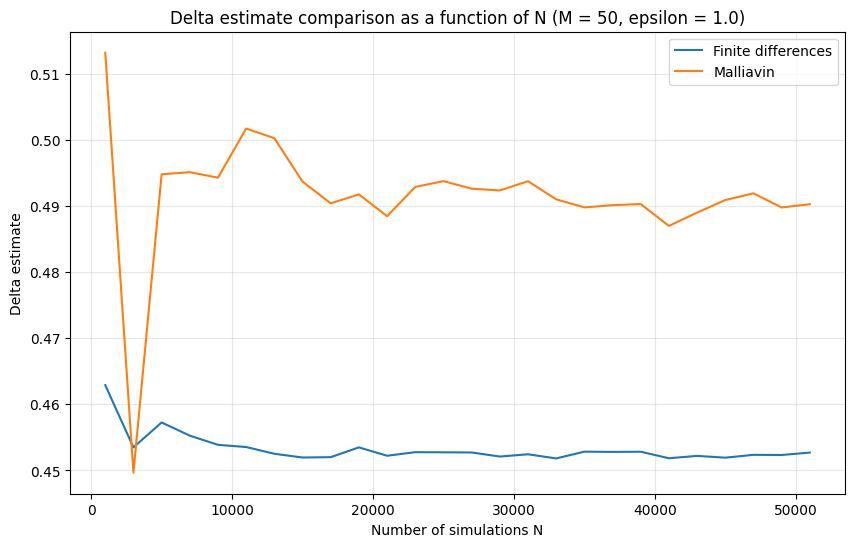

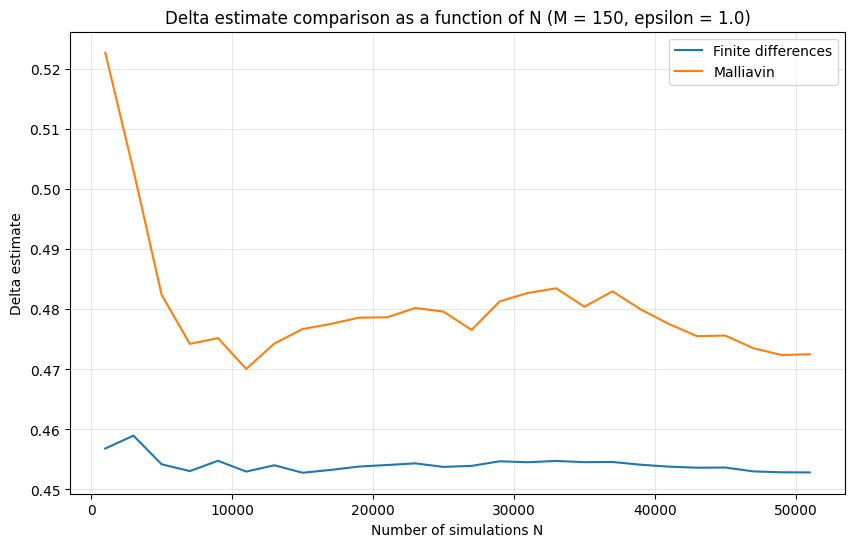

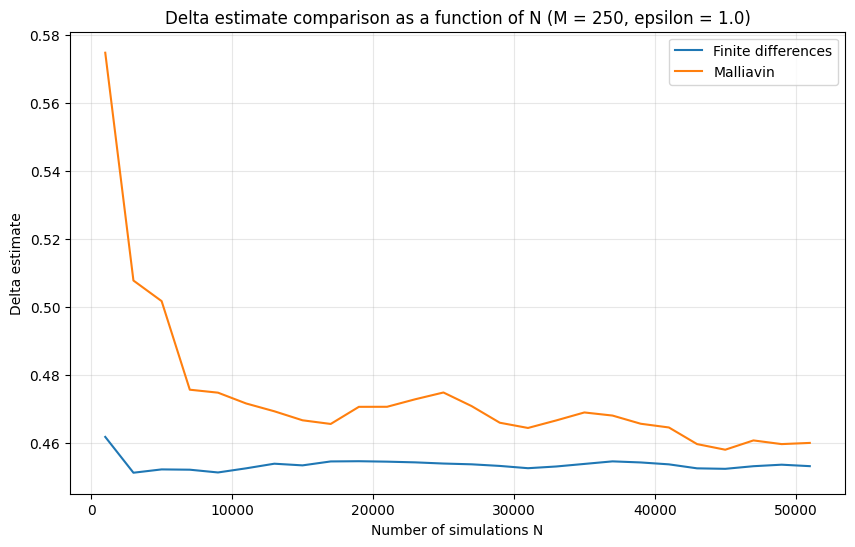

In [103]:
for M_plot in M_values:
    subset = comparison_df[comparison_df["M"] == M_plot]

    plt.figure(figsize=(10, 6))
    plt.plot(subset["N"], subset["FD Delta estimate"], label="Finite differences")
    plt.plot(subset["N"], subset["Malliavin Delta estimate"], label="Malliavin")

    plt.xlabel("Number of simulations N")
    plt.ylabel("Delta estimate")
    plt.title(f"Delta estimate comparison as a function of N (M = {M_plot}, epsilon = {epsilon_benchmark})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

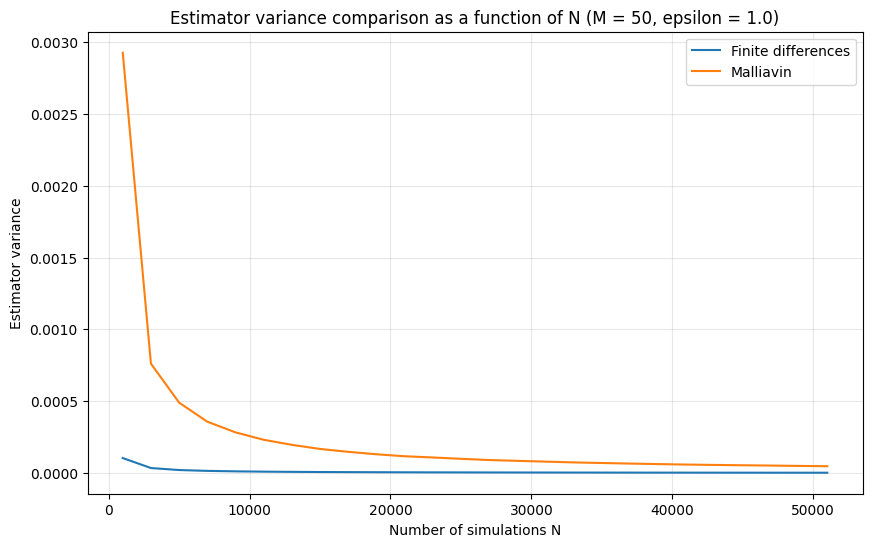

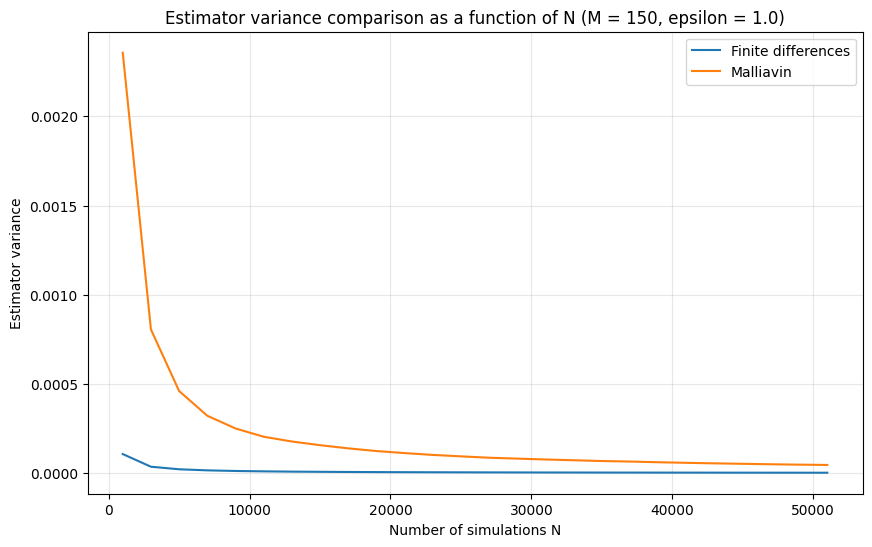

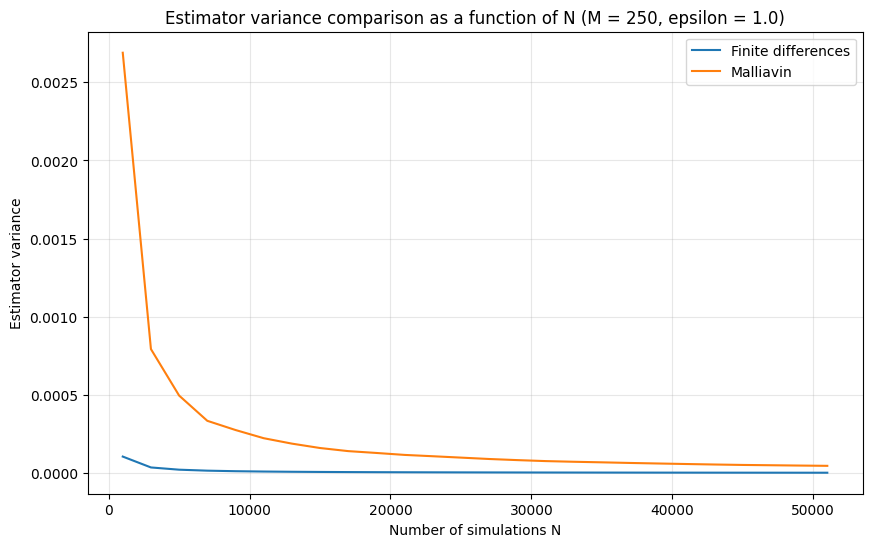

In [104]:
for M_plot in M_values:
    subset = comparison_df[comparison_df["M"] == M_plot]

    plt.figure(figsize=(10, 6))
    plt.plot(subset["N"], subset["FD Estimator variance"], label="Finite differences")
    plt.plot(subset["N"], subset["Malliavin Estimator variance"], label="Malliavin")

    plt.xlabel("Number of simulations N")
    plt.ylabel("Estimator variance")
    plt.title(f"Estimator variance comparison as a function of N (M = {M_plot}, epsilon = {epsilon_benchmark})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

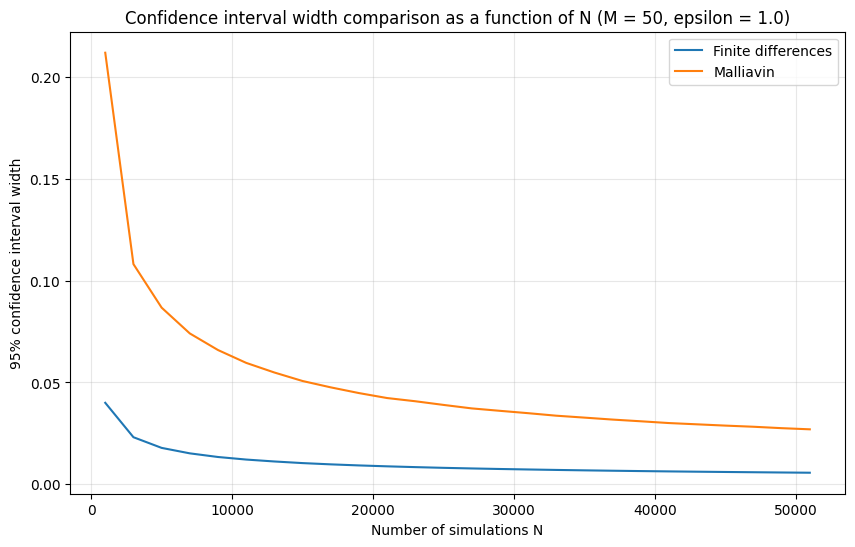

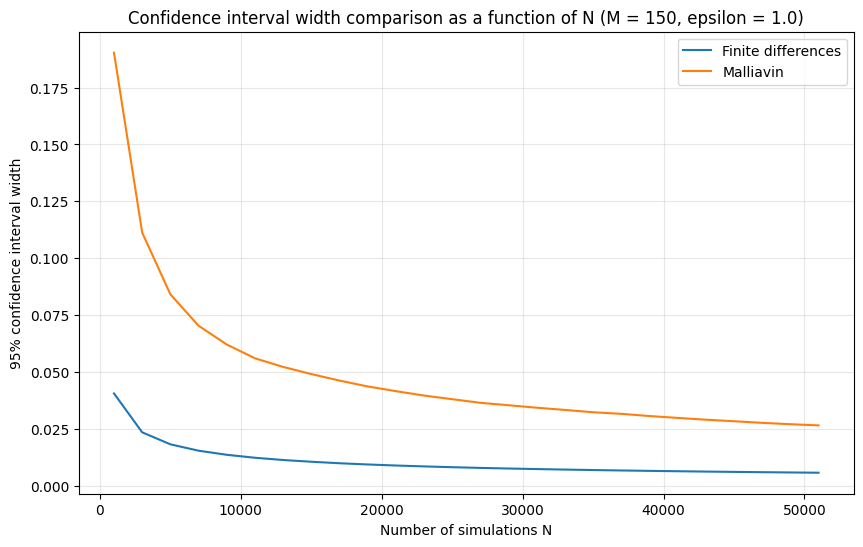

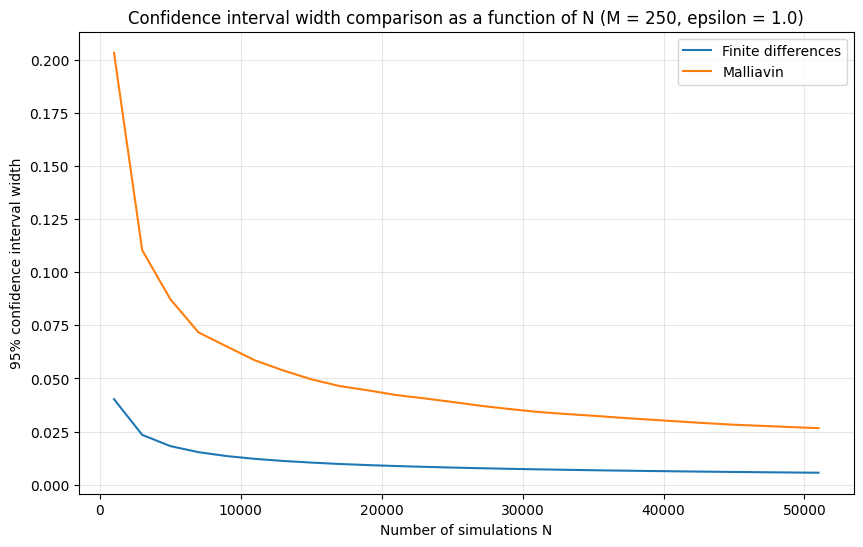

In [105]:
for M_plot in M_values:
    subset = comparison_df[comparison_df["M"] == M_plot]

    plt.figure(figsize=(10, 6))
    plt.plot(subset["N"], subset["FD CI width"], label="Finite differences")
    plt.plot(subset["N"], subset["Malliavin CI width"], label="Malliavin")

    plt.xlabel("Number of simulations N")
    plt.ylabel("95% confidence interval width")
    plt.title(f"Confidence interval width comparison as a function of N (M = {M_plot}, epsilon = {epsilon_benchmark})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [106]:
summary_comparison = comparison_final[
    [
        "M", "N",
        "FD Delta estimate", "FD Estimator variance", "FD CI width",
        "Malliavin Delta estimate", "Malliavin Estimator variance", "Malliavin CI width",
        "Variance ratio (Mal/FD)", "CI width ratio (Mal/FD)"
    ]
].copy()

summary_comparison

,M,N,FD Delta estimate,FD Estimator variance,FD CI width,Malliavin Delta estimate,Malliavin Estimator variance,Malliavin CI width,Variance ratio (Mal/FD),CI width ratio (Mal/FD)
0,50,51000,0.452692,0.000002,0.005656,0.490259,0.000047,0.026986,22.767152,4.771494
1,150,51000,0.452840,0.000002,0.005651,0.472527,0.000046,0.026468,21.939644,4.683977
2,250,51000,0.453044,0.000002,0.005644,0.459891,0.000046,0.026625,22.256118,4.717639


In [107]:
summary_comparison_rounded = summary_comparison.copy()

for col in summary_comparison_rounded.columns:
    if col not in ["M", "N"]:
        summary_comparison_rounded[col] = summary_comparison_rounded[col].astype(float).round(6)

summary_comparison_rounded

,M,N,FD Delta estimate,FD Estimator variance,FD CI width,Malliavin Delta estimate,Malliavin Estimator variance,Malliavin CI width,Variance ratio (Mal/FD),CI width ratio (Mal/FD)
0,50,51000,0.452692,0.000002,0.005656,0.490259,0.000047,0.026986,22.767152,4.771494
1,150,51000,0.452840,0.000002,0.005651,0.472527,0.000046,0.026468,21.939644,4.683977
2,250,51000,0.453044,0.000002,0.005644,0.459891,0.000046,0.026625,22.256118,4.717639
